# 第一阶段：Chen2020 高保真基准充电仿真

## 目标

建立可重复运行的 PyBaMM `Chen2020` 高保真虚拟电芯，检查 25 ℃下 1C、1.5C 和 2C CC–CV 充电从 10% 到 80% SOC 的时间、电压和温度表现。

本阶段不优化控制律。它的作用是确认模型、单位、数据接口和约束是否合理，并为二阶 RC＋双节点热模型辨识提供基准数据。

**符号约定：**项目统一规定充电电流为正；PyBaMM 原始电流在导出时已反号。

## 成功标准与实验计划

1. Chen2020 DFN＋集总热模型可以稳定运行；
2. 导出时间、电流、电压、SOC 和温度，单位明确；
3. SOC 单调增加、时间严格递增、数据无非有限值；
4. 识别 4.2 V、10 A 和 35 ℃约束是否被触发；
5. 不预设更高 C-rate 一定能完成 10%→80% 充电。

In [1]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import Image, display

# 禁用 PyBaMM 匿名遥测，使实验可以离线、稳定地复现。
os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")

# 无论从项目根目录还是 notebooks 目录启动，都自动找到配置和输出文件。
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase1.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

from battery_fast_charge.config import load_config
from battery_fast_charge.runner import run_baseline_scan

# YAML 是本实验唯一的参数入口；修改工况时优先改配置，不要散改代码。
config = load_config(PROJECT_ROOT / "configs" / "phase1.yaml")
print(f"预测时域: {config.control.prediction_horizon_s:.0f} s")

预测时域: 300 s


## 运行或复用基准数据

交付版本已经包含正式运行结果。将 `RUN_SIMULATION` 改为 `True` 可以重新调用高保真模型；首次运行三个工况通常需要几十秒。

In [2]:
RUN_SIMULATION = False

summary_path = PROJECT_ROOT / "outputs" / "metrics" / "baseline_summary.csv"
# False 表示直接读取已交付结果；改为 True 才会重新运行三个 DFN 仿真。
if RUN_SIMULATION or not summary_path.exists():
    summary = run_baseline_scan(config, PROJECT_ROOT)
else:
    summary = pd.read_csv(summary_path)

# 只展示最关心的指标；完整字段仍保存在 summary 和输出 CSV 中。
columns = [
    "c_rate",
    "reached_target_soc",
    "final_soc",
    "charge_time_min",
    "maximum_voltage_v",
    "maximum_temperature_c",
    "maximum_charge_current_a",
    "temperature_limit_exceeded",
]
display(summary[columns].round(4))

,c_rate,reached_target_soc,final_soc,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_charge_current_a,temperature_limit_exceeded
0,1.0,True,0.8004,42.8481,4.2,37.5054,5.0002,True
1,1.5,True,0.8001,31.0589,4.2,46.5032,7.5006,True
2,2.0,False,0.5267,NaN,4.2,53.2688,10.0000,True


## 电流、电压、SOC 与温度曲线

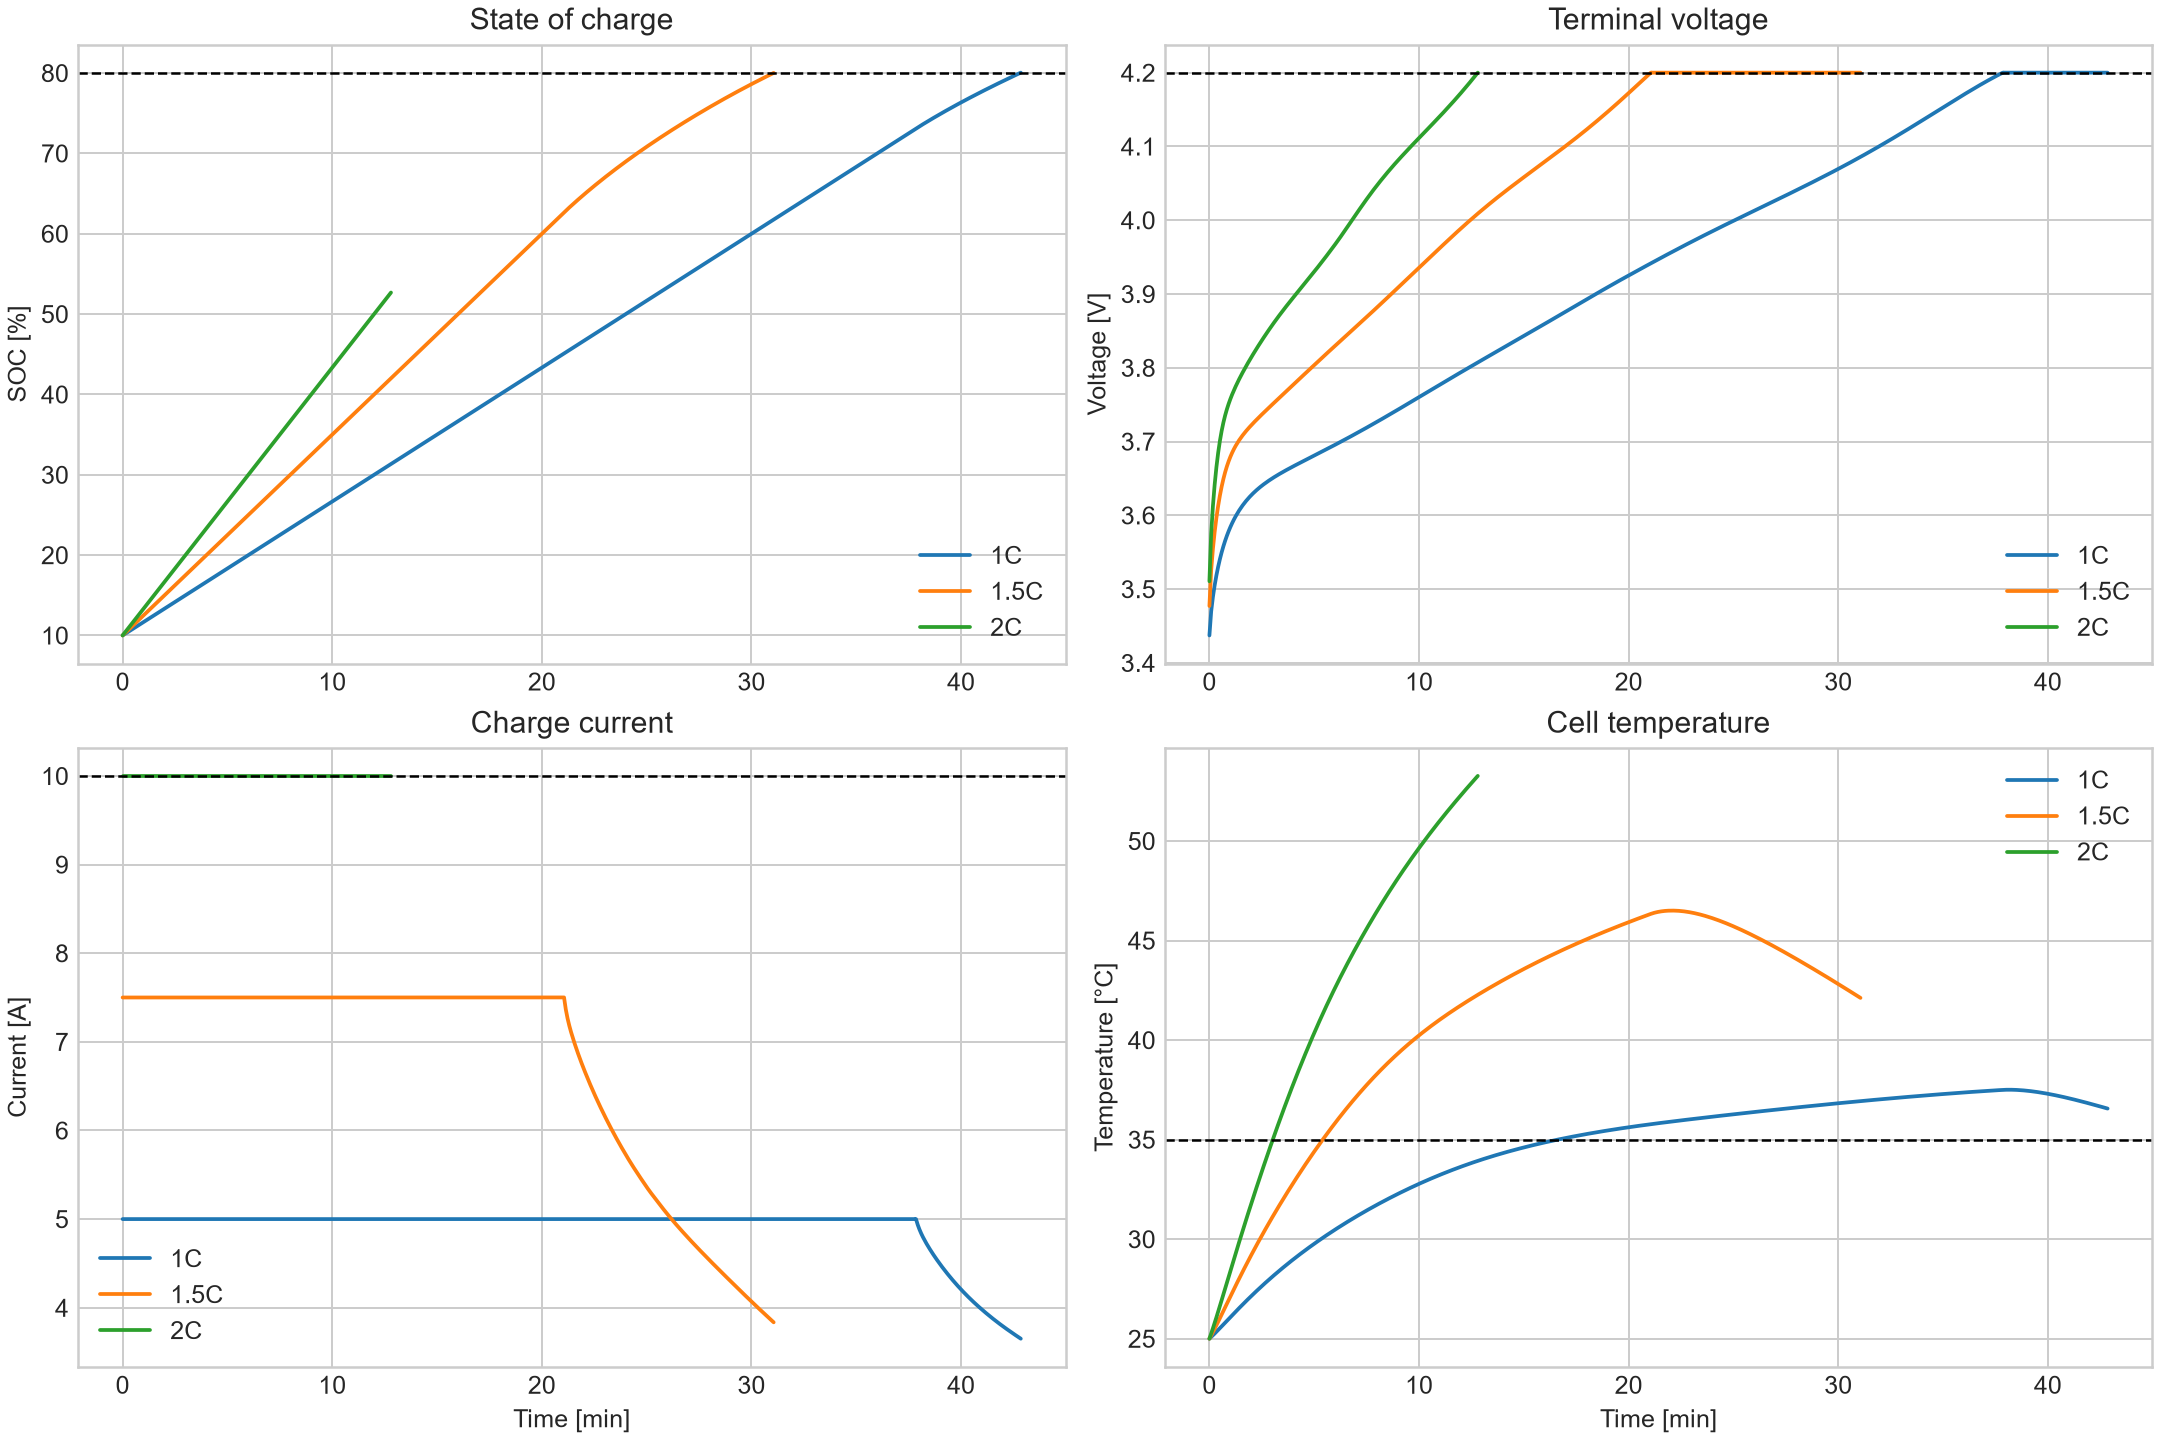

In [3]:
figure_path = PROJECT_ROOT / "outputs" / "figures" / "chen2020_cccv_baseline_scan.png"
# 这里显示 runner.py 已保存的四联图，不会重新计算仿真。
display(Image(filename=str(figure_path)))

## 数据质量检查

以下检查只验证轨迹结构和基本物理方向，不把温度超限当成软件错误。温度超限是本次基线扫描要识别的工程结果。

In [4]:
check_columns = [column for column in summary.columns if column.startswith("check_")]
display(summary[["c_rate"] + check_columns])
# 如果出现缺失值、时间倒退、SOC 明显下降或充电电流为负，立即停止 Notebook。
assert summary[check_columns].all(axis=None), '至少一项轨迹完整性检查未通过'

,c_rate,check_nonempty,check_finite,check_time_monotonic,check_soc_nondecreasing,check_charge_current_nonnegative
0,1.0,True,True,True,True,True
1,1.5,True,True,True,True,True
2,2.0,True,True,True,True,True


## 当前结论

- 1C 和 1.5C 工况能够达到 80% SOC，但都超过研究性温度上限 35 ℃；
- 1.5C 比 1C 更快，但温升明显更高；
- 2C 工况在当前 Chen2020 DFN＋热模型及 CC–CV 设置下没有达到 80% SOC，不能把它当作有效快充基线；
- 电压和电流上限实现正常，所有已导出轨迹通过时间、SOC、符号和有限值检查；
- 后续 MPC 必须主动处理温度约束，而不能只对电流和电压限幅。

这些结果是模型内的仿真结论，不是 LG M50 实物电芯安全或性能认证。

## 下一阶段

1. 从高保真模型生成 OCV、HPPC/脉冲和热响应虚拟试验；
2. 辨识二阶 RC＋双节点热模型；
3. 使用独立动态轨迹验证简化模型；
4. 在简化模型上构建带电压、电流、温度和电流变化率约束的 MPC。